# 2. Block Maxima и GEV

**Цели:** оценить GEV и возвратные уровни. Полные блоки считаются приближённо независимыми.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


(0.9676403775384641,
    return_period  return_level   ci_lower      ci_upper
 0           10.0      9.547074   5.293165     24.807950
 1           50.0     37.549196   8.591225    449.749022
 2          100.0     71.431672  10.606745   1671.291794
 3          500.0    331.143450  17.866370  35363.239494)

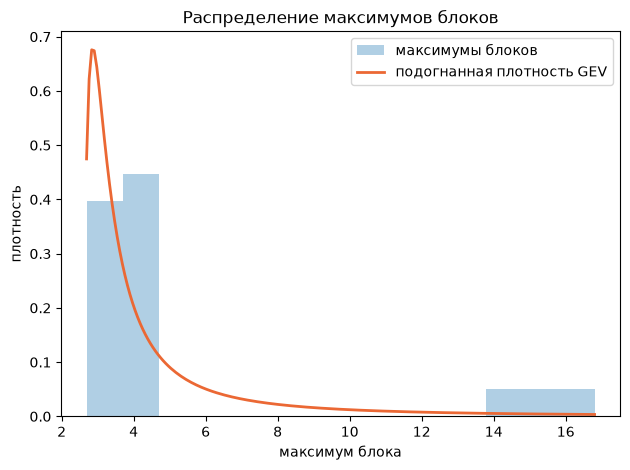

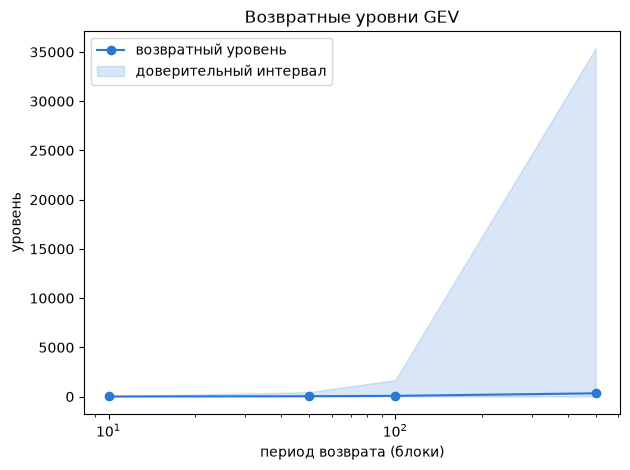

In [2]:
from evt_demo import EVTAnalyzer, generate_time_series_with_extreme_events
from evt_demo.visualization import plot_gev_distribution, plot_return_levels
series, _ = generate_time_series_with_extreme_events(seed=42)
a = EVTAnalyzer(); fit = a.fit_gev_block_maxima(series, 100)
levels = a.calculate_gev_return_levels(fit, n_bootstrap=50, seed=42)
plot_gev_distribution(fit, "../figures/notebook_02_gev.png")
plot_return_levels(levels, "../figures/notebook_02_returns.png")
fit.xi, levels

SciPy возвращает `c=-xi`; API demo возвращает принятую в EVT величину $\xi$. Периоды здесь измеряются в блоках.

**Самопроверка:** 1) Что теряется при увеличении блока? 2) Что означает знак $\xi$? 3) Почему далёкая экстраполяция неопределённа?